In [1]:

import torch
import numpy as np
from PIL import Image
import torchvision
from torchvision import datasets, models, transforms
from glob import glob
from datapipe import WGM_dataset
from train import *
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [10]:
VAL_CSV_PATH = "/home/mahirwar/Desktop/Monika/npsad_data/monika/LBD/Intermediate_data/val_redmarked_downsampled.csv"

In [31]:
crops_paths = pd.read_csv(VAL_CSV_PATH)["crop_filepath"].values

In [11]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(1024),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        #transforms.FiveCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([-0.0601, -0.0667, -0.0616],[0.9118, 0.9479, 0.9625])
        #transforms.Normalize([0.8965, 0.8875, 0.9023],[0.0807, 0.0911, 0.0849])
        #transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(1024),
        #transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([-0.0601, -0.0667, -0.0616],[0.9118, 0.9479, 0.9625])
        #transforms.Normalize([0.8965, 0.8875, 0.9023],[0.0807, 0.0911, 0.0849])
       # transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        #transforms.Resize(256),
        #transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([-0.0601, -0.0667, -0.0616],[0.9118, 0.9479, 0.9625])
        #transforms.Normalize([0.8965, 0.8875, 0.9023],[0.0807, 0.0911, 0.0849])
        #transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

batch_size = 8

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [12]:
val_wgm = WGM_dataset(VAL_CSV_PATH, data_transforms, "val", batch_size)

In [13]:
val_loader = val_wgm.build_data_pipe()
val_datasize = val_wgm.dataset_size()

In [14]:
dataloaders = { "val": val_loader}
dataset_sizes = {'val':val_datasize}

In [15]:
path = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/3uctrn1o10.pth'
model_ft = load_saved_model(path)

In [16]:
model_ft = model_ft.to(device)
model_ft.fc_backup = model_ft.fc
model_ft.fc = nn.Sequential()

In [19]:
actual_labels = []
wsi_names = []
feature_list=[]
for i, (wsi, inputs, labels) in enumerate(dataloaders['val']):
    inputs=inputs.squeeze(0)
    labels = labels.squeeze(0)
    inputs = inputs.to(device)
    labels = labels.to(device)
    features = model_ft(inputs)
    feature_list.extend(features.cpu().tolist())
    actual_labels.extend(labels.tolist())
    wsi=[x[0] for x in wsi]
    wsi_names.extend(wsi)

In [20]:
tsne_model = TSNE(n_components=2, random_state=0, learning_rate='auto', init='random', perplexity=50)

In [ ]:
projections = tsne_model.fit_transform(np.array(feature_list))

In [34]:
tsne_data = np.vstack((embeddings_2d.T, actual_labels)).T
tsne_df = pd.DataFrame(data=tsne_data, columns=("Dim_1", "Dim_2", "label"))

fig = px.scatter(
    embeddings_2d, x=0, y=1,
    color=tsne_df.label, labels={'color': 'label'}
)
fig.show()

In [27]:
# for plotting
import os

import matplotlib.offsetbox as osb
import matplotlib.pyplot as plt

# for resizing images to thumbnails
import torchvision.transforms.functional as functional
from matplotlib import rcParams as rcp
from PIL import Image

# for clustering and 2d representations
from sklearn import random_projection

In [23]:
embeddings_2d = projections

In [24]:
# normalize the embeddings to fit in the [0, 1] square
M = np.max(embeddings_2d, axis=0)
m = np.min(embeddings_2d, axis=0)
embeddings_2d = (embeddings_2d - m) / (M - m)

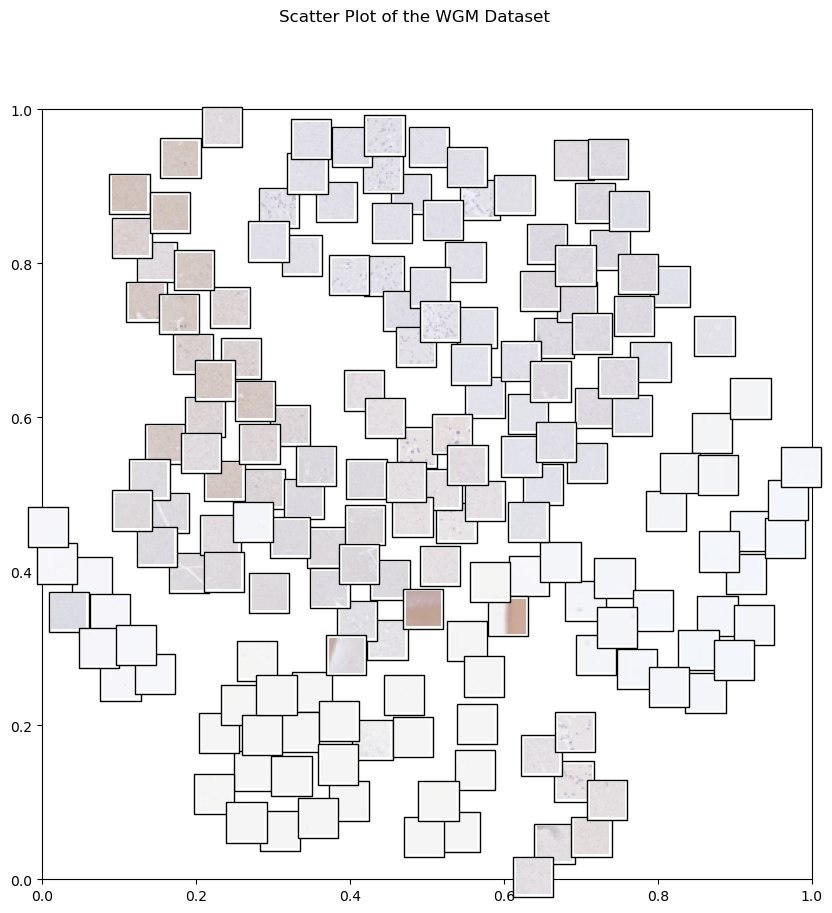

In [42]:
def get_scatter_plot_with_thumbnails():
    """Creates a scatter plot with image overlays."""
    # initialize empty figure and add subplot
    fig = plt.figure(figsize=(10,10))
    fig.suptitle("Scatter Plot of the WGM Dataset")
    ax = fig.add_subplot(1, 1, 1)
    # shuffle images and find out which images to show
    shown_images_idx = []
    shown_images = np.array([[1.0, 1.0]])
    iterator = [i for i in range(embeddings_2d.shape[0])]
    np.random.shuffle(iterator)
    for i in iterator:
        # only show image if it is sufficiently far away from the others
        dist = np.sum((embeddings_2d[i] - shown_images) ** 2, 1)
        if np.min(dist) < 2e-3:
            continue
        shown_images = np.r_[shown_images, [embeddings_2d[i]]]
        shown_images_idx.append(i)

    # plot image overlays
    for idx in shown_images_idx:
        thumbnail_size = int(rcp["figure.figsize"][0] * 4.0)
        #path = os.path.join(path_to_data, filenames[idx])
        path = crops_paths[idx]
        img = Image.open(path)
        img = functional.resize(img, thumbnail_size)
        img = np.array(img)
        img_box = osb.AnnotationBbox(
            osb.OffsetImage(img, cmap=plt.cm.gray_r),
            embeddings_2d[idx],
            pad=0.2,
        )
        ax.add_artist(img_box)

    # set aspect ratio
    ratio = 1.0 / ax.get_data_ratio()
    ax.set_aspect(ratio, adjustable="box")


# get a scatter plot with thumbnail overlays
get_scatter_plot_with_thumbnails()